In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA

In [6]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
print(df.head())

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


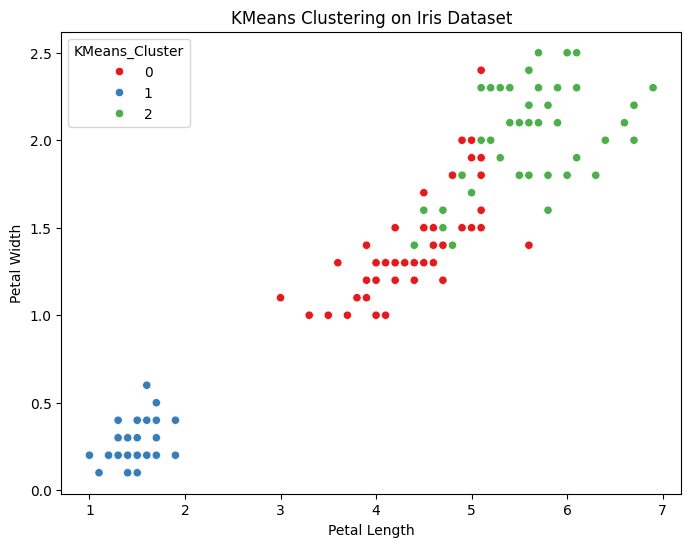

In [8]:

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(scaled_data)

df["KMeans_Cluster"] = kmeans_labels

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=df["petal length (cm)"],
    y=df["petal width (cm)"],
    hue=df["KMeans_Cluster"],
    palette="Set1"
)
plt.title("KMeans Clustering on Iris Dataset")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.show()


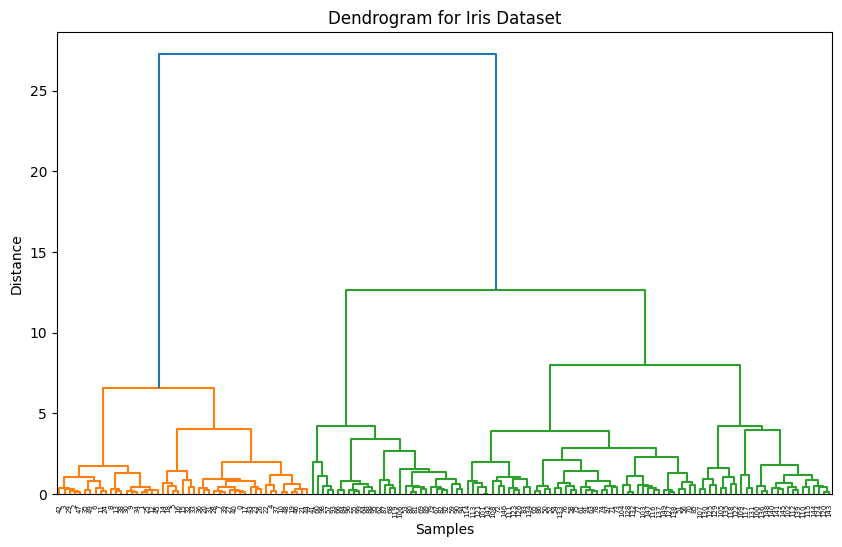

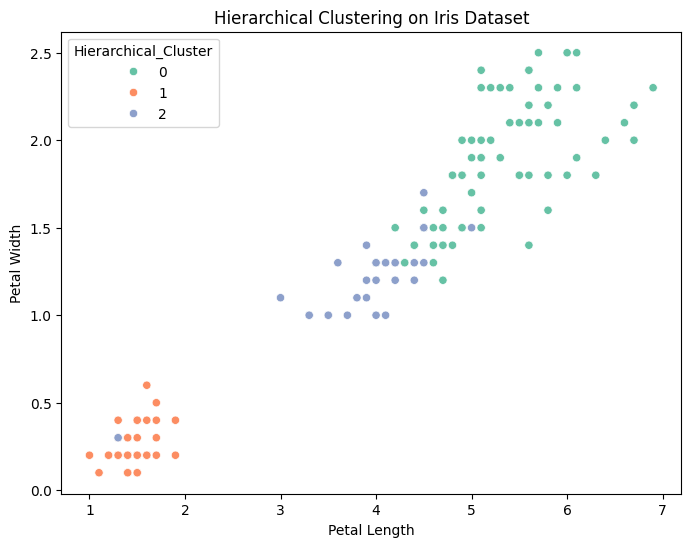

In [9]:

linked = linkage(scaled_data, method="ward")

plt.figure(figsize=(10, 6))
dendrogram(linked)
plt.title("Dendrogram for Iris Dataset")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

hierarchical = AgglomerativeClustering(n_clusters=3, linkage="ward")
hierarchical_labels = hierarchical.fit_predict(scaled_data)

df["Hierarchical_Cluster"] = hierarchical_labels

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=df["petal length (cm)"],
    y=df["petal width (cm)"],
    hue=df["Hierarchical_Cluster"],
    palette="Set2"
)
plt.title("Hierarchical Clustering on Iris Dataset")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.show()
